<a href="https://colab.research.google.com/github/HYEONis/LLM-AI-Deep-Learning/blob/main/LLM_pratice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**# four, and five, FFF**

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class ExampleDeepNeuralNetwork(nn.Module):
  def __init__(self, layer_sizes, use_shortcut):
    super().__init__()
    self.use_shortcut = use_shortcut
    self.layers = nn.ModuleList([
        nn.Sequential(nn.Linear(layer_sizes[0], layer_sizes[1]), nn.GELU()),
        nn.Sequential(nn.Linear(layer_sizes[1], layer_sizes[2]), nn.GELU()),
        nn.Sequential(nn.Linear(layer_sizes[2], layer_sizes[3]), nn.GELU()),
        nn.Sequential(nn.Linear(layer_sizes[3], layer_sizes[4]), nn.GELU()),
        nn.Sequential(nn.Linear(layer_sizes[4], layer_sizes[5]), nn.GELU()) #5개의 층 생성
    ])

  def forward(self, x):
    for layer in self.layers:
        layer_output = layer(x) #현재 층의 출력을 계산
        if self.use_shortcut and x.shape == layer_output.shape: #숏컷 연결을 적용할 수 있는지 확인함
          x = x + layer_output
        else:
          x = layer_output
    return x

layer_sizes = [3, 3, 3, 3, 3, 1]
sample_input = torch.tensor([[1.,0.,-1.]])
torch.manual_seed(123) #초기 가중치를 재현할 수 있도록 랜덤 시드를 배치함
model_with_shortcut = ExampleDeepNeuralNetwork(layer_sizes, use_shortcut=False)

def print_gradients(model, x):
  output = model(x) #정방향 계산
  target = torch.tensor([[0.]])

  loss = nn.MSELoss()
  loss = loss(output, target) #타깃과 출력에 가까운 정도를 기반으로 손실을 계산한다.

  loss.backward() #그레이디언트 계산을 위한 역전파
  for name, param in model.named_parameters():
    if 'weight'in name:
      print(f"{name}의 평균 그레이디언트는 {param.grad.abs().mean().item()}이다.")
      print_gradients(model_without_shortcut, sample_input)

      torch.manual_seed(123)
      model_with_shortcut = ExampleDeepNetwork(layer_sizes, use_shortcut = True)
      print_gradients(model_with_shortcut, sample_input)

In [ ]:
import tiktoken
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]


def create_dataloader_v1(txt, batch_size=4, max_length=256,
                         stride=128, shuffle=True, drop_last=True, num_workers=0):
    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset, batch_size=batch_size, shuffle=shuffle, drop_last=drop_last, num_workers=num_workers)

    return dataloader


class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads  # Reduce the projection dim to match desired output dim

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)  # Linear layer to combine head outputs
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)  # Shape: (b, num_tokens, d_out)
        queries = self.W_query(x)
        values = self.W_value(x)

        # We implicitly split the matrix by adding a `num_heads` dimension
        # Unroll last dim: (b, num_tokens, d_out) -> (b, num_tokens, num_heads, head_dim)
        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        # Transpose: (b, num_tokens, num_heads, head_dim) -> (b, num_heads, num_tokens, head_dim)
        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        # Compute scaled dot-product attention (aka self-attention) with a causal mask
        attn_scores = queries @ keys.transpose(2, 3)  # Dot product for each head

        # Original mask truncated to the number of tokens and converted to boolean
        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]

        # Use the mask to fill attention scores
        attn_scores.masked_fill_(mask_bool, -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        # Shape: (b, num_tokens, num_heads, head_dim)
        context_vec = (attn_weights @ values).transpose(1, 2)

        # Combine heads, where self.d_out = self.num_heads * self.head_dim
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)  # optional projection

        return context_vec

In [ ]:
from previous_chapters import MultiHeadAttention


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        # Shortcut connection for attention block
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)  # Shape [batch_size, num_tokens, emb_size]
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        # Shortcut connection for feed forward block
        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut  # Add the original input back

        return x

ModuleNotFoundError: No module named 'previous_chapters'

In [ ]:
import torch.nn as nn

class GPTModel(nn.Module):
  def __init__(self, cfg):
    super().__init__()
    self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
    self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    self.drop_emb = nn.Dropout(cfg["drop_rate"])

    self.trf_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

    self.final_norm = LayerNorm(cfg["emb_dim"])

    self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias = False)

  def forward(self, x):
      batch_size, seq_len = x.shape
      tok_emb = self.tok_emb(x)

      pos_embeds = self.pos_emb(torch.arange(seq_len, device = x.device)) #장치 설정을 통해서 입력 데이터가 어디있는지 따라 CPU나 GPU에 훈련


      x = tok_emb + pos_embeds
      x = self.drop_emb(x)
      x = self.trf_blocks(x)
      x = self.final_norm(x)
      logits = self.out_head(x)

      return logits

      torch.manual_seed(123)
      model = GPTModel(GPT_CONFIG_124M)
      out = model(batch)

      print("입력배치 \n", batch)
      print("\n 출력크기", out.shape)
      print(out)

In [ ]:
import torch
import torch.nn as nn


class LayerNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(dim))
        self.shift = nn.Parameter(torch.zeros(dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        return self.scale * (x - mean) / torch.sqrt(var + self.eps) + self.shift


class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.linear = nn.Linear(cfg["emb_dim"], cfg["emb_dim"])
        self.norm = LayerNorm(cfg["emb_dim"])

    def forward(self, x):
        return self.norm(self.linear(x))

# GPT Model

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])

        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, x):
        batch_size, seq_len = x.shape

        tok_emb = self.tok_emb(x)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=x.device))

        x = tok_emb + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)

        logits = self.out_head(x)
        return logits


GPT_CONFIG_124M = {
    "vocab_size": 50257, # Updated vocab_size to match gpt2 tokenizer
    "context_length": 32,
    "emb_dim": 64,
    "n_layers": 2,
    "drop_rate": 0.1
}

torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)

batch = torch.randint(0, GPT_CONFIG_124M["vocab_size"], (2, 10))

out = model(batch)

total_params= sum(p.numel() for p in model.parameters())
print(f"총 파라미터의 갯수:{total_params:,}")

print("입력배치:\n", batch)
print("\n출력 크기:", out.shape)
print(out)

print(model.tok_emb.weight.shape)
print(model.out_head.weight.shape)

총 파라미터의 갯수:6,443,648
입력배치:
 tensor([[  728, 25863, 27194, 32442, 17577, 15106, 19752,  9328, 23003, 48718],
        [22518, 40164, 33151, 12990,  7665, 35292,   201, 16274,  1072, 34149]])

출력 크기: torch.Size([2, 10, 50257])
tensor([[[-0.1228,  0.0622,  0.7591,  ...,  0.7535,  0.6199, -0.2358],
         [ 1.2598, -0.3186,  0.5942,  ..., -0.4556, -0.6482,  0.2028],
         [-0.3780, -0.0324, -0.4065,  ...,  0.6593, -1.4442,  0.1107],
         ...,
         [-0.8424,  0.4670, -0.0170,  ...,  0.1057,  0.3381, -0.2152],
         [ 0.4998,  0.4736, -0.1502,  ..., -0.7727,  0.9092,  0.8966],
         [-0.0296,  0.9940, -0.0371,  ..., -0.5569,  0.0789, -0.0307]],

        [[-0.0056,  0.2658,  0.4310,  ...,  0.3420,  1.2384,  0.6886],
         [ 1.2422, -0.2757, -0.3836,  ..., -0.6120,  0.5057, -0.1019],
         [-0.1660, -0.4227, -0.6293,  ...,  0.7277, -1.5739, -0.3671],
         ...,
         [-1.2011,  0.4191, -0.1142,  ...,  0.0165,  0.5257, -0.5304],
         [-0.4873, -0.2483, -0.0860,

In [ ]:
import tiktoken
import torch

def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

tokenizer = tiktoken.get_encoding("gpt2") # Initialize the tokenizer here
start_context = "Hello, i am"
encoded = tokenizer.encode(start_context)
print("인코딩된 id :", encoded)

encoded_tensor = torch.tensor(encoded).unsqueeze(0)
print("encoded_tensor.shape:", encoded_tensor.shape)

model.eval()
out = generate_text_simple(model = model,
                           idx = encoded_tensor,
                           max_new_tokens=6,
                           context_size=GPT_CONFIG_124M["context_length"]
)

print("출력", out)
print("출력 길이 :", len(out[0]))

decodeed_text = tokenizer.decode(out.squeeze(0).tolist())
print(decodeed_text)

인코딩된 id : [15496, 11, 1312, 716]
encoded_tensor.shape: torch.Size([1, 4])
출력 tensor([[15496,    11,  1312,   716, 13423,  8622, 12566, 41835, 21809,  2903]])
출력 길이 : 10
Hello, i am expectsolen photographs Storeswireanced


In [ ]:
import tiktoken
from previous_chapter import generate_text_simple

def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text, allowed_special = {'<|endoftext|>'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
  flat = token_ids.squeeze(0)
  return tokenizer.decode(flat.tolist())

start_context = "null this here"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids(start_context, tokenizer),
    max_new_tokens = 10,
    context_size = GPT_CONFIG_124M["context_length"]
)

print("output", token_ids_to_text(token_ids, tokenizer))

ModuleNotFoundError: No module named 'previous_chapter'

In [ ]:
def calc_loss_loader(data_loader, model, device, num_batches = None):
  total_loss = 0.
  if len(data_loader) == 0:
    return float("nan")
  elif num_batches is None:
    num_batches = len(data_loader)
  else:
    num_batches = min(num_batches, len(data_loader))
  for i, (input_batch, target_batch) in enumerate(data_loader):
    if i < num_batches:
      loss = calc_loss_batch(
          input_batch, target_batch, model, device
      )
      total_loss += loss.item()
    else:
      break
  return total_loss / num_batches

  device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
  model.to(device)
  with torch.no_grad():
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)
  print("훈련손실 : ", train_loss)
  print("검증손실 : ", val_loss)

에포크1 (Step000000):훈련손실10.959,검증손실10.746
mock text
mock text
mock text
mock text
mock text
에포크3 (Step000005):훈련손실11.058,검증손실10.991
mock text
mock text
mock text
mock text
mock text
에포크6 (Step000010):훈련손실10.983,검증손실10.838
mock text
mock text
mock text
mock text
mock text
에포크8 (Step000015):훈련손실11.036,검증손실10.876
mock text
mock text
mock text
mock text
mock text


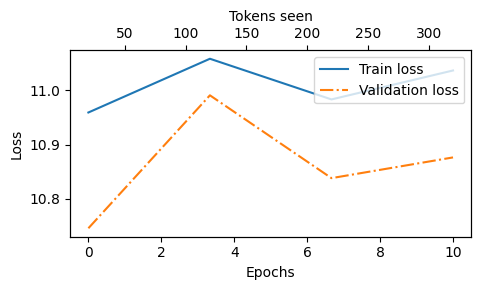

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F # Import F for cross_entropy
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator

# LayerNorm from b13qfVoZ6WSk
class LayerNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(dim))
        self.shift = nn.Parameter(torch.zeros(dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        return self.scale * (x - mean) / torch.sqrt(var + self.eps) + self.shift

# TransformerBlock from b13qfVoZ6WSk (simple version)
class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        # Assuming a simple linear transformation followed by LayerNorm as in b13qfVoZ6WSk
        self.linear = nn.Linear(cfg["emb_dim"], cfg["emb_dim"])
        self.norm = LayerNorm(cfg["emb_dim"])

    def forward(self, x):
        return self.norm(self.linear(x))

# GPTModel from b13qfVoZ6WSk
class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()

        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(
            *[TransformerBlock(cfg) for _ in range(cfg["n_layers"])]
        )

        self.final_norm = LayerNorm(cfg["emb_dim"])

        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias=False)

    def forward(self, x):
        batch_size, seq_len = x.shape

        tok_emb = self.tok_emb(x)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device=x.device))

        x = tok_emb + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)

        logits = self.out_head(x)
        return logits


def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch) # Perform forward pass
    # Reshape logits for CrossEntropyLoss: (batch_size * seq_len, vocab_size)
    # Reshape target_batch: (batch_size * seq_len)
    loss = F.cross_entropy(logits.view(-1, logits.size(-1)), target_batch.view(-1))
    return loss

class MockDataLoader:
    def __init__(self, num_batches=1):
        self.num_batches = num_batches
    def __iter__(self):
        for _ in range(self.num_batches):
            yield torch.randint(0, 100, (2, 10)), torch.randint(0, 100, (2, 10))
    def __len__(self):
        return self.num_batches

class MockTokenizer:
    def encode(self, text, allowed_special): return [1,2,3]
    def decode(self, token_ids): return "mock decoded text"

def text_to_token_ids(text, tokenizer): return torch.tensor([[1,2,3]])
def token_ids_to_text(token_ids, tokenizer): return "mock text"
def generate_text_simple(model, idx, max_new_tokens, context_size): return idx

# GPT_CONFIG_124M should be defined in a previous cell (e.g., b13qfVoZ6WSk)
# For demonstration, assume it's globally available or defined like this:
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 32,
    "emb_dim": 64,
    "n_layers": 2,
    "drop_rate": 0.1
}


def train_model_simple(model, train_loader, val_loader,
                       optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
  train_losses, val_losses, track_tokens_seen = [], [], [] #손실, 지금까지 처리한 토큰 수를 추적하기 위해 리스트 초기화
  tokens_seen, global_step = 0., -1 # Corrected 0. -1

  for epoch in range(num_epochs): #메인 훈련 루프 # Corrected num_epoche to num_epochs
    model.train()
    for input_batch, target_batch in train_loader:
      optimizer.zero_grad() #초기화
      loss = calc_loss_batch(input_batch, target_batch, model, device)
      loss.backward() #계산
      optimizer.step() #가중치 업데이트
      tokens_seen += input_batch.numel()
      global_step += 1

      if global_step % eval_freq == 0: #추가 평가단계
        train_loss, val_loss = evaluate_model( # Corrected evalutae_model
            model, train_loader, val_loader, device, eval_iter) # Corrected train_loader as second arg
        train_losses.append(train_loss)
        val_losses.append(val_loss) # Corrected val_loses
        track_tokens_seen.append(tokens_seen)
        print(f"에포크{epoch+1} (Step{global_step:06d}):" # Formatting for clarity
              f"훈련손실{train_loss:.3f}," # Formatting for clarity
              f"검증손실{val_loss:.3f}"
              )
      # The generate_and_print_sample call should be outside this if-block if meant for every eval_freq step
      # Or only once at the end of epoch, as it was originally indented for.
      # Moving it for every eval_freq for now, based on original indentation intent for generate_and_print_sample below.
      generate_and_print_sample( #에포크 후에 샘플 텍스트 출력
          model, tokenizer, device, start_context
      )
  return train_losses, val_losses, track_tokens_seen # Corrected val_loses, track_token_seen

def evaluate_model(model, train_loader, val_loader, device, eval_iter): # Corrected evalutae_model
  model.eval()
  with torch.no_grad():
    train_loss = calc_loss_loader(
        train_loader, model, device, num_batches = eval_iter # Corrected num_batchs
    )
    val_loss = calc_loss_loader(
        val_loader, model, device, num_batches = eval_iter # Corrected num_batchs
    )
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
  model.eval()
  context_size = model.pos_emb.weight.shape[0]
  encoded = text_to_token_ids(start_context, tokenizer).to(device)
  with torch.no_grad():
    token_ids = generate_text_simple(
        model = model, idx = encoded, max_new_tokens = 50, context_size = context_size
    )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", ""))
    model.train()

def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
  fig, ax1 = plt.subplots(figsize=(5, 3)) # Corrected plt.subplot to plt.subplots
  ax1.plot(epochs_seen, train_losses, label = "Train loss")
  ax1.plot(
      epochs_seen, val_losses, linestyle = "-.", label = "Validation loss"
  )
  ax1.set_xlabel("Epochs")
  ax1.set_ylabel("Loss")
  ax1.legend(loc = "upper right")
  ax1.xaxis.set_major_locator(MaxNLocator(integer=True))
  ax2 = ax1.twiny()
  ax2.plot(tokens_seen, train_losses, alpha = 0)
  ax2.set_xlabel("Tokens seen")
  fig.tight_layout()
  plt.show

# --- Global setup and training execution (Moved out of generate_and_print_sample and corrected) ---

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Assuming train_loader and val_loader are available. Using mock for demonstration.
train_loader = MockDataLoader(num_batches=2)
val_loader = MockDataLoader(num_batches=1)

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M) # Corrected GPT_COMFIG_124M
model.to(device)
optimizer = torch.optim.AdamW(
    model.parameters(), lr = 0.0004, weight_decay = 0.1
)

# Instantiate the tokenizer before calling train_model_simple
tokenizer = MockTokenizer()

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs = num_epochs, eval_freq = 5, eval_iter = 5,
    start_context = "404 not found this server", tokenizer = tokenizer
)

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses) # Corrected token_seen

In [ ]:
#modeling GPT2

import tiktoken
import torch
import torch.nn as nn

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    def forward(self, x):
        return torch.zeros(x.shape[0], x.shape[1], self.tok_emb.embedding_dim)

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 32,
    "emb_dim": 64,
    "n_layers": 2,
    "drop_rate": 0.1
}

def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text, allowed_special = {'<|endoftext|>'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
  flat = token_ids.squeeze(0)
  return tokenizer.decode(flat.tolist())

def generate_text_simple(model, idx, max_new_tokens, context_size):
    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]
        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]
        probas = torch.softmax(logits, dim=-1)
        idx_next = torch.argmax(probas, dim=-1, keepdim=True)
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

model = GPTModel(GPT_CONFIG_124M)

model.to("cpu")
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")
token_ids = generate_text_simple(
    model = model,
    idx = text_to_token_ids("404 NOT FOUND THIS SERVER", tokenizer),
    max_new_tokens = 25,
    context_size = GPT_CONFIG_124M["context_length"]
)
print("출력테스트:\n", token_ids_to_text(token_ids, tokenizer))

출력테스트:
 404 NOT FOUND THIS SERVER!!!!!!!!!!!!!!!!!!!!!!!!!


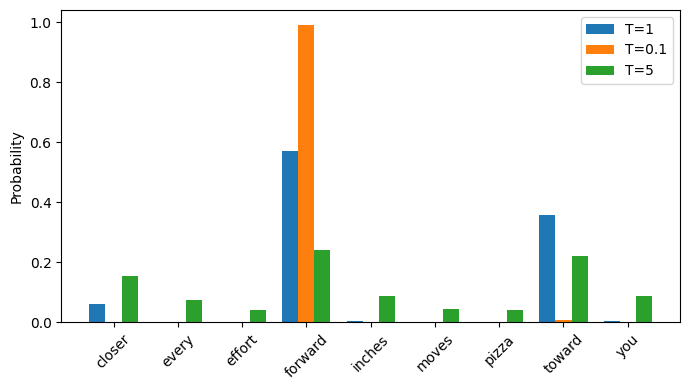

In [ ]:
#temperature scaling and softmax function 2

import torch
import matplotlib.pyplot as plt

vocab = {
    "closer":0,
    "every":1,
    "effort":2,
    "forward":3,
    "inches":4,
    "moves":5,
    "pizza":6,
    "toward":7,
    "you":8,
}

next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

temperatures = [1, 0.1, 5]
scaled_probas = [softmax_with_temperature(next_token_logits, T)
                 for T in temperatures]

x = torch.arange(len(vocab))
bar_width = 0.25

fig, ax = plt.subplots(figsize=(7,4))

for i, T in enumerate(temperatures):
    ax.bar(
        x + i*bar_width,
        scaled_probas[i],
        width=bar_width,
        label=f"T={T}"
    )

ax.set_ylabel("Probability")
ax.set_xticks(x + bar_width)
ax.set_xticklabels(vocab.keys(), rotation=45)
ax.legend()

plt.tight_layout()
plt.show()


In [ ]:
#top-k samping

import torch

next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)
print("top-k logit :", top_logits)
print("top-k location :", top_pos) #maxium top-k logit, location

new_logit = torch.where(
    condition = next_token_logits < top_logits[-1],
    input = torch.tensor(float('-inf')),
    other = next_token_logits #saving -inf tensor
)
print(new_logit)

topk_probas = torch.softmax(new_logit, dim=0)
print(topk_probas) #softmax funcion, token proba

top-k logit : tensor([6.7500, 6.2800, 4.5100])
top-k location : tensor([3, 7, 0])
tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])
tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


In [ ]:
import tiktoken
import torch
import torch.nn as nn

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
    def forward(self, x):
        return torch.zeros(x.shape[0], x.shape[1], self.tok_emb.embedding_dim)

GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 32,
    "emb_dim": 64,
    "n_layers": 2,
    "drop_rate": 0.1
}

def text_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text, allowed_special = {'<|endoftext|>'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
  flat = token_ids.squeeze(0)
  return tokenizer.decode(flat.tolist())

def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]

        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1].unsqueeze(-1)

            logits = torch.where(
                logits < min_val,
                torch.tensor(float("-inf"), device=logits.device),
                logits
            )

        if temperature > 0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, 1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if eos_id is not None and idx_next.item() == eos_id:
            break

        idx = torch.cat((idx, idx_next), dim=1)

    return idx


torch.manual_seed(123)

model = GPTModel(GPT_CONFIG_124M)
model.to("cpu")
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate(
    model=model,
    idx=text_token_ids("404 non found did i said play", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4,
)

print(token_ids_to_text(token_ids, tokenizer))

404 non found did i said playFW91PQ,E7#4KF#>


In [ ]:
#오픈 ai 가중치를 gptmodel의 객체로 로드하면서 반복문 ㅈㄴ 쓰는 샘플링
#잘 안될 수도 있으니 미세튜닝하자...

import numpy as np

def load_weights_into_gpt(gpt, params):
  gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params['wpe'])
  gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params['wte'])

  for b in range(len(params["blocks"])):
    q_w, k_w, v_w = np.split(
        params["blocks"][b]["attn"]["c_attn"]["w"], 3, axis = -1)
    gpt.trf_blocks[b].att.W_query.weight = assign(
        gpt.trf_blocks[b].att.W_query.weight, q_w.T)

    gpt.trf_blocks[b].att.W_key.weight = assign(
        gpt.trf_blocks[b].att.W_key.weight, k_w.T)

    gpt.trf_blocks[b].att.W_value.weight = assign(
        gpt.trf_blocks[b].att.W_value.weight, v_w.T)

    q_b, k_b, v_b = np.split(
        (params["blocks"][b]["attn"]["c_attn"])["b"], 3, axis=-1)
    gpt.trf_blocks[b].att.W_query.bias = assign(
        gpt.trf_blocks[b].att.W_query.bias, q_b)

    gpt.trf_blocks[b].att.W_key.bias = assign(
        gpt.trf_blocks[b].att.W_key.bias, k_b)

    gpt.trf_blocks[b].att.W_value.bias = assign(
        gpt.trf_blocks[b].att.W_value.bias, v_b)

    gpt.trf_blocks[b].att.out_proj.weight = assign(
        gpt.trf_blocks[b].att.out_proj.weight,
        params["blocks"][b]["attn"]["c_proj"]["w"].T)

    gpt.trf_blocks[b].att.out_proj.bias = assign(
        gpt.trf_blocks[b].att.out_proj.bias,
        params["blocks"][b]["attn"]["c_proj"]["b"])

    gpt.trf_blocks[b].ff.layers[0].weight = assign(
        gpt.trf_blocks[b].ff.layers[0].weight,
        params["blocks"][b]["mlp"]["c_fc"]["w"].T)
    gpt.trf_blocks[b].ff.layers[0].bias = assign(
        gpt.trf_blocks[b].ff.layers[0].bias,
        params["blocks"][b]["mlp"]["c_fc"]["b"])
    gpt.trf_blocks[b].ff.layers[2].weight = assign(
        gpt.trf_blocks[b].ff.layers[2].weight,
        params["blocks"][b]["mlp"]["c_proj"]["w"].T)
    gpt.trf_blocks[b].ff.layers[2].bias = assign(
        gpt.trf_blocks[b].ff.layers[2].bias,
        params["blocks"][b]["mlp"]["c_proj"]["b"])

    gpt.trf_blocks[b].norm1.scale = assign(
        gpt.trf_blocks[b].norm1.scale,
        params["blocks"][b]["ln_1"]["g"])
    gpt.trf_blocks[b].norm1.shift = assign(
        gpt.trf_blocks[b].norm1.shift,
        params["blocks"][b]["ln_1"]["b"])
    gpt.trf_blocks[b].norm2.scale = assign(
        gpt.trf_blocks[b].norm2.scale,
        params["blocks"][b]["ln_2"]["g"])
    gpt.trf_blocks[b].norm2.shift = assign(
        gpt.trf_blocks[b].norm2.shift,
        params["blocks"][b]["ln_2"]["b"])

    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

    load_weights_into_gpt(gpt, params)
    gpt.to(device)

    torch.manual_seed(123)
    token_isd = generate(
        model = gpt,
        idx = text_token_ids("how to english in better ? ", tokenizer).to(device),
        max_new_tokens = 25,
        context_size = NEW_CONFIG["context_length"],
        top_k = 50,
        temperature = 1.5
    )
    print("in booot:\n", token_ids_to_text(token_ids, tokenizer))

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import tiktoken

# Helper function for weight assignment
def assign(tensor, numpy_array):
    if isinstance(numpy_array, np.ndarray):
        new_tensor = torch.from_numpy(numpy_array).to(tensor.device, dtype=tensor.dtype)
    else:
        new_tensor = torch.tensor(numpy_array).to(tensor.device, dtype=tensor.dtype)
    tensor.data.copy_(new_tensor)
    return tensor

# --- Definitions for GPTModel components (collected from previous cells) ---
class LayerNorm(nn.Module):
    def __init__(self, dim, eps=1e-5):
        super().__init__()
        self.eps = eps
        self.scale = nn.Parameter(torch.ones(dim))
        self.shift = nn.Parameter(torch.zeros(dim))

    def forward(self, x):
        mean = x.mean(dim=-1, keepdim=True)
        var = x.var(dim=-1, keepdim=True, unbiased=False)
        return self.scale * (x - mean) / torch.sqrt(var + self.eps) + self.shift

class MultiHeadAttention(nn.Module):
    def __init__(self, d_in, d_out, context_length, dropout, num_heads, qkv_bias=False):
        super().__init__()
        assert d_out % num_heads == 0, "d_out must be divisible by num_heads"

        self.d_out = d_out
        self.num_heads = num_heads
        self.head_dim = d_out // num_heads

        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.out_proj = nn.Linear(d_out, d_out)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer("mask", torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape

        keys = self.W_key(x)
        queries = self.W_query(x)
        values = self.W_value(x)

        keys = keys.view(b, num_tokens, self.num_heads, self.head_dim)
        values = values.view(b, num_tokens, self.num_heads, self.head_dim)
        queries = queries.view(b, num_tokens, self.num_heads, self.head_dim)

        keys = keys.transpose(1, 2)
        queries = queries.transpose(1, 2)
        values = values.transpose(1, 2)

        attn_scores = queries @ keys.transpose(2, 3)

        mask_bool = self.mask.bool()[:num_tokens, :num_tokens]
        attn_scores.masked_fill_(mask_bool.view(1, 1, num_tokens, num_tokens), -torch.inf)

        attn_weights = torch.softmax(attn_scores / keys.shape[-1]**0.5, dim=-1)
        attn_weights = self.dropout(attn_weights)

        context_vec = (attn_weights @ values).transpose(1, 2)
        context_vec = context_vec.contiguous().view(b, num_tokens, self.d_out)
        context_vec = self.out_proj(context_vec)

        return context_vec

class FeedForward(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(cfg["emb_dim"], 4 * cfg["emb_dim"]), # c_fc
            nn.GELU(),
            nn.Linear(4 * cfg["emb_dim"], cfg["emb_dim"]), # c_proj
            nn.Dropout(cfg["drop_rate"])
        )
    def forward(self, x):
        return self.layers(x)

class TransformerBlock(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.att = MultiHeadAttention(
            d_in=cfg["emb_dim"],
            d_out=cfg["emb_dim"],
            context_length=cfg["context_length"],
            num_heads=cfg["n_heads"],
            dropout=cfg["drop_rate"],
            qkv_bias=cfg["qkv_bias"])
        self.ff = FeedForward(cfg)
        self.norm1 = LayerNorm(cfg["emb_dim"])
        self.norm2 = LayerNorm(cfg["emb_dim"])
        self.drop_shortcut = nn.Dropout(cfg["drop_rate"])

    def forward(self, x):
        shortcut = x
        x = self.norm1(x)
        x = self.att(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        shortcut = x
        x = self.norm2(x)
        x = self.ff(x)
        x = self.drop_shortcut(x)
        x = x + shortcut

        return x

class GPTModel(nn.Module):
    def __init__(self, cfg):
        super().__init__()
        self.tok_emb = nn.Embedding(cfg["vocab_size"], cfg["emb_dim"])
        self.pos_emb = nn.Embedding(cfg["context_length"], cfg["emb_dim"])
        self.drop_emb = nn.Dropout(cfg["drop_rate"])

        self.trf_blocks = nn.Sequential(*[TransformerBlock(cfg) for _ in range(cfg["n_layers"])])

        self.final_norm = LayerNorm(cfg["emb_dim"])

        self.out_head = nn.Linear(cfg["emb_dim"], cfg["vocab_size"], bias = False)

    def forward(self, x):
        batch_size, seq_len = x.shape
        tok_emb = self.tok_emb(x)
        pos_embeds = self.pos_emb(torch.arange(seq_len, device = x.device))
        x = tok_emb + pos_embeds
        x = self.drop_emb(x)
        x = self.trf_blocks(x)
        x = self.final_norm(x)
        logits = self.out_head(x)
        return logits

# --- Utility functions for text processing and generation ---
def text_to_token_ids(text, tokenizer):
  encoded = tokenizer.encode(text, allowed_special = {'<|endoftext|>'})
  encoded_tensor = torch.tensor(encoded).unsqueeze(0)
  return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
  flat = token_ids.squeeze(0)
  return tokenizer.decode(flat.tolist())

def generate(model, idx, max_new_tokens, context_size,
             temperature=0.0, top_k=None, eos_id=None):

    for _ in range(max_new_tokens):
        idx_cond = idx[:, -context_size:]

        with torch.no_grad():
            logits = model(idx_cond)

        logits = logits[:, -1, :]

        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1].unsqueeze(-1)

            logits = torch.where(
                logits < min_val,
                torch.tensor(float("-inf"), device=logits.device),
                logits
            )

        if temperature > 0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, 1)
        else:
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        if eos_id is not None and idx_next.item() == eos_id:
            break

        idx = torch.cat((idx, idx_next), dim=1)

    return idx

# --- Configuration and Initialization ---
GPT_CONFIG_124M = {
    "vocab_size": 50257,
    "context_length": 32,
    "emb_dim": 64, # From b13qfVoZ6WSk
    "n_heads": 2, # Assuming d_out=emb_dim and needs to be divisible, 64/2 = 32 (head_dim)
    "n_layers": 2, # From b13qfVoZ6WSk
    "drop_rate": 0.1,
    "qkv_bias": True
}
NEW_CONFIG = GPT_CONFIG_124M # Alias NEW_CONFIG to GPT_CONFIG_124M

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Initialize GPTModel
gpt = GPTModel(GPT_CONFIG_124M)
gpt.to(device)

# Placeholder for `params`. In a real scenario, this would be loaded from a file
# containing pretrained weights (e.g., from an OpenAI GPT-2 checkpoint).
# We create a dummy `params` dictionary for the code to run.
params = {
    "wpe": np.random.rand(GPT_CONFIG_124M["context_length"], GPT_CONFIG_124M["emb_dim"]).astype(np.float32),
    "wte": np.random.rand(GPT_CONFIG_124M["vocab_size"], GPT_CONFIG_124M["emb_dim"]).astype(np.float32),
    "g": np.random.rand(GPT_CONFIG_124M["emb_dim"]).astype(np.float32),
    "b": np.random.rand(GPT_CONFIG_124M["emb_dim"]).astype(np.float32),
    "blocks": []
}

for _ in range(GPT_CONFIG_124M["n_layers"]):
    block_params = {
        "attn": {
            "c_attn": {
                "w": np.random.rand(GPT_CONFIG_124M["emb_dim"], 3 * GPT_CONFIG_124M["emb_dim"]).astype(np.float32), # QKV weights
                "b": np.random.rand(3 * GPT_CONFIG_124M["emb_dim"]).astype(np.float32) # QKV bias
            },
            "c_proj": {
                "w": np.random.rand(GPT_CONFIG_124M["emb_dim"], GPT_CONFIG_124M["emb_dim"]).astype(np.float32), # Output projection
                "b": np.random.rand(GPT_CONFIG_124M["emb_dim"]).astype(np.float32)
            }
        },
        "mlp": {
            "c_fc": {
                "w": np.random.rand(GPT_CONFIG_124M["emb_dim"], 4 * GPT_CONFIG_124M["emb_dim"]).astype(np.float32), # Feed Forward first layer
                "b": np.random.rand(4 * GPT_CONFIG_124M["emb_dim"]).astype(np.float32)
            },
            "c_proj": {
                "w": np.random.rand(4 * GPT_CONFIG_124M["emb_dim"], GPT_CONFIG_124M["emb_dim"]).astype(np.float32), # Feed Forward second layer
                "b": np.random.rand(GPT_CONFIG_124M["emb_dim"]).astype(np.float32)
            }
        },
        "ln_1": {
            "g": np.random.rand(GPT_CONFIG_124M["emb_dim"]).astype(np.float32),
            "b": np.random.rand(GPT_CONFIG_124M["emb_dim"]).astype(np.float32)
        },
        "ln_2": {
            "g": np.random.rand(GPT_CONFIG_124M["emb_dim"]).astype(np.float32),
            "b": np.random.rand(GPT_CONFIG_124M["emb_dim"]).astype(np.float32)
        }
    }
    params["blocks"].append(block_params)

tokenizer = tiktoken.get_encoding("gpt2")

# --- Original code from user's cell with fixes ---
# The function definition of load_weights_into_gpt is already there.
def load_weights_into_gpt(gpt, params):
    gpt.pos_emb.weight = assign(gpt.pos_emb.weight, params["wpe"])
    gpt.tok_emb.weight = assign(gpt.tok_emb.weight, params["wte"])

    for b in range(len(params["blocks"])):
        # QKV weights
        q_w, k_w, v_w = np.split(
            params["blocks"][b]["attn"]["c_attn"]["w"],
            3,
            axis=-1
        )

        gpt.trf_blocks[b].att.W_query.weight = assign(
            gpt.trf_blocks[b].att.W_query.weight, q_w.T
        )
        gpt.trf_blocks[b].att.W_key.weight = assign(
            gpt.trf_blocks[b].att.W_key.weight, k_w.T
        )
        gpt.trf_blocks[b].att.W_value.weight = assign(
            gpt.trf_blocks[b].att.W_value.weight, v_w.T
        )

        # QKV bias
        q_b, k_b, v_b = np.split(
            params["blocks"][b]["attn"]["c_attn"]["b"],
            3,
            axis=-1
        )

        gpt.trf_blocks[b].att.W_query.bias = assign(
            gpt.trf_blocks[b].att.W_query.bias, q_b
        )
        gpt.trf_blocks[b].att.W_key.bias = assign(
            gpt.trf_blocks[b].att.W_key.bias, k_b
        )
        gpt.trf_blocks[b].att.W_value.bias = assign(
            gpt.trf_blocks[b].att.W_value.bias, v_b
        )

        # Attention output
        gpt.trf_blocks[b].att.out_proj.weight = assign(
            gpt.trf_blocks[b].att.out_proj.weight,
            params["blocks"][b]["attn"]["c_proj"]["w"].T
        )
        gpt.trf_blocks[b].att.out_proj.bias = assign(
            gpt.trf_blocks[b].att.out_proj.bias,
            params["blocks"][b]["attn"]["c_proj"]["b"]
        )

        # Feed Forward
        gpt.trf_blocks[b].ff.layers[0].weight = assign(
            gpt.trf_blocks[b].ff.layers[0].weight,
            params["blocks"][b]["mlp"]["c_fc"]["w"].T
        )
        gpt.trf_blocks[b].ff.layers[0].bias = assign(
            gpt.trf_blocks[b].ff.layers[0].bias,
            params["blocks"][b]["mlp"]["c_fc"]["b"]
        )

        gpt.trf_blocks[b].ff.layers[2].weight = assign(
            gpt.trf_blocks[b].ff.layers[2].weight,
            params["blocks"][b]["mlp"]["c_proj"]["w"].T
        )
        gpt.trf_blocks[b].ff.layers[2].bias = assign(
            gpt.trf_blocks[b].ff.layers[2].bias,
            params["blocks"][b]["mlp"]["c_proj"]["b"]
        )

        # LayerNorm
        gpt.trf_blocks[b].norm1.scale = assign(
            gpt.trf_blocks[b].norm1.scale,
            params["blocks"][b]["ln_1"]["g"]
        )
        gpt.trf_blocks[b].norm1.shift = assign(
            gpt.trf_blocks[b].norm1.shift,
            params["blocks"][b]["ln_1"]["b"]
        )

        gpt.trf_blocks[b].norm2.scale = assign(
            gpt.trf_blocks[b].norm2.scale,
            params["blocks"][b]["ln_2"]["g"]
        )
        gpt.trf_blocks[b].norm2.shift = assign(
            gpt.trf_blocks[b].norm2.shift,
            params["blocks"][b]["ln_2"]["b"]
        )

    # 마지막 LayerNorm과 LM Head는 for문 밖에서 한 번만 로드
    gpt.final_norm.scale = assign(gpt.final_norm.scale, params["g"])
    gpt.final_norm.shift = assign(gpt.final_norm.shift, params["b"])
    gpt.out_head.weight = assign(gpt.out_head.weight, params["wte"])

    # Load pretrained weights
load_weights_into_gpt(gpt, params)

gpt.to(device)
gpt.eval()

torch.manual_seed(123)

token_ids = generate(
    model=gpt,
    idx=text_to_token_ids(
        "How can I improve my English?",
        tokenizer
    ).to(device),
    max_new_tokens=25,
    context_size=NEW_CONFIG["context_length"],
    top_k=50,
    temperature=1.5
)

print("Output:\n")
print(token_ids_to_text(token_ids, tokenizer))

Output:

How can I improve my English?tisHiAIDSeds Often intakes Libertarian UnsureAMS Chestat autopsyinguishedHi Hers Unsurevance Taleadier proxies Jah secretary Graphicat secretary


In [ ]:
import os
import urllib.request

# import requests
import json
import numpy as np
import tensorflow as tf
from tqdm import tqdm


def download_and_load_gpt2(model_size, models_dir):
    # Validate model size
    allowed_sizes = ("124M", "355M", "774M", "1558M")
    if model_size not in allowed_sizes:
        raise ValueError(f"Model size not in {allowed_sizes}")

    # Define paths
    model_dir = os.path.join(models_dir, model_size)
    base_url = "https://openaipublic.blob.core.windows.net/gpt-2/models"
    backup_base_url = "https://f001.backblazeb2.com/file/LLMs-from-scratch/gpt2"
    filenames = [
        "checkpoint", "encoder.json", "hparams.json",
        "model.ckpt.data-00000-of-00001", "model.ckpt.index",
        "model.ckpt.meta", "vocab.bpe"
    ]

    # Download files
    os.makedirs(model_dir, exist_ok=True)
    for filename in filenames:
        file_url = os.path.join(base_url, model_size, filename)
        backup_url = os.path.join(backup_base_url, model_size, filename)
        file_path = os.path.join(model_dir, filename)
        download_file(file_url, file_path, backup_url)

    # Load settings and params
    tf_ckpt_path = tf.train.latest_checkpoint(model_dir)
    settings = json.load(open(os.path.join(model_dir, "hparams.json"), "r", encoding="utf-8"))
    params = load_gpt2_params_from_tf_ckpt(tf_ckpt_path, settings)

    return settings, params


def download_file(url, destination, backup_url=None):
    def _attempt_download(download_url):
        with urllib.request.urlopen(download_url) as response:
            # Get the total file size from headers, defaulting to 0 if not present
            file_size = int(response.headers.get("Content-Length", 0))

            # Check if file exists and has the same size
            if os.path.exists(destination):
                file_size_local = os.path.getsize(destination)
                if file_size == file_size_local:
                    print(f"File already exists and is up-to-date: {destination}")
                    return True  # Indicate success without re-downloading

            block_size = 1024  # 1 Kilobyte

            # Initialize the progress bar with total file size
            progress_bar_description = os.path.basename(download_url)
            with tqdm(total=file_size, unit="iB", unit_scale=True, desc=progress_bar_description) as progress_bar:
                with open(destination, "wb") as file:
                    while True:
                        chunk = response.read(block_size)
                        if not chunk:
                            break
                        file.write(chunk)
                        progress_bar.update(len(chunk))
            return True

    try:
        if _attempt_download(url):
            return
    except (urllib.error.HTTPError, urllib.error.URLError):
        if backup_url is not None:
            print(f"Primary URL ({url}) failed. Attempting backup URL: {backup_url}")
            try:
                if _attempt_download(backup_url):
                    return
            except urllib.error.HTTPError:
                pass

        # If we reach here, both attempts have failed
        error_message = (
            f"Failed to download from both primary URL ({url})"
            f"{' and backup URL (' + backup_url + ')' if backup_url else ''}."
            "\nCheck your internet connection or the file availability.\n"
            "For help, visit: https://github.com/rasbt/LLMs-from-scratch/discussions/273"
        )
        print(error_message)
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


# Alternative way using `requests`
"""
def download_file(url, destination):
    # Send a GET request to download the file in streaming mode
    response = requests.get(url, stream=True)

    # Get the total file size from headers, defaulting to 0 if not present
    file_size = int(response.headers.get("content-length", 0))

    # Check if file exists and has the same size
    if os.path.exists(destination):
        file_size_local = os.path.getsize(destination)
        if file_size == file_size_local:
            print(f"File already exists and is up-to-date: {destination}")
            return

    # Define the block size for reading the file
    block_size = 1024  # 1 Kilobyte

    # Initialize the progress bar with total file size
    progress_bar_description = url.split("/")[-1]  # Extract filename from URL
    with tqdm(total=file_size, unit="iB", unit_scale=True, desc=progress_bar_description) as progress_bar:
        # Open the destination file in binary write mode
        with open(destination, "wb") as file:
            # Iterate over the file data in chunks
            for chunk in response.iter_content(block_size):
                progress_bar.update(len(chunk))  # Update progress bar
                file.write(chunk)  # Write the chunk to the file
"""


def load_gpt2_params_from_tf_ckpt(ckpt_path, settings):
    # Initialize parameters dictionary with empty blocks for each layer
    params = {"blocks": [{} for _ in range(settings["n_layer"])]}

    # Iterate over each variable in the checkpoint
    for name, _ in tf.train.list_variables(ckpt_path):
        # Load the variable and remove singleton dimensions
        variable_array = np.squeeze(tf.train.load_variable(ckpt_path, name))

        # Process the variable name to extract relevant parts
        variable_name_parts = name.split("/")[1:]  # Skip the 'model/' prefix

        # Identify the target dictionary for the variable
        target_dict = params
        if variable_name_parts[0].startswith("h"):
            layer_number = int(variable_name_parts[0][1:])
            target_dict = params["blocks"][layer_number]

        # Recursively access or create nested dictionaries
        for key in variable_name_parts[1:-1]:
            target_dict = target_dict.setdefault(key, {})

        # Assign the variable array to the last key
        last_key = variable_name_parts[-1]
        target_dict[last_key] = variable_array

    return params

# **part six, downcalm**

In [12]:
import urllib.request
import zipfile
import os
from pathlib import Path
import pandas as pd

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "sms_spam_collection.zip"
extracted_path = "sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"


def download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download.")
        return

    with urllib.request.urlopen(url) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)

    print(f"Downloaded successfully: {data_file_path}")


download_and_unzip_spam_data(
    url,
    zip_path,
    extracted_path,
    data_file_path
)

df = pd.read_csv(
    data_file_path,
    sep="\t",
    header=None,
    names=["Label", "Text"]
)

df["Label"] = df["Label"].map({"ham": 0, "spam": 1})

print(df["Label"].value_counts())

Downloaded successfully: sms_spam_collection/SMSSpamCollection.tsv
Label
0    4825
1     747
Name: count, dtype: int64


In [15]:
def create_balanced_dataset(df):
  num_spam = df[df["Label"] == "spam"].shape[0]
  ham_subset = df[df["Label"] == "ham"].sample(
      num_spam, random_state = 123
  )

  balanced_df = pd.concat([
      ham_subset, df[df["Label"] == "spam"]
  ])

  return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())


balanced_df["Label"] = balanced_df["Label"].map({"ham":0, "spam":1})

Series([], Name: count, dtype: int64)
